# Grocery exploratory data analysis

Author: Maria Jorda

Date: 22 Feb 2026

In this notebook 5 different datasets are loaded and merged into one, and an exploratory data analysis is also done. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data download 

In [2]:
df_orders = pd.read_parquet('/Users/mariajordamunoz/Documents/formación/data science - zrive/semana 2/zrive-grocery-datasets/orders.parquet')
print(df_orders.shape)
df_orders.head()

(8773, 6)


,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."


In [3]:
df_items_asked_for = pd.read_parquet('/Users/mariajordamunoz/Documents/formación/data science - zrive/semana 2/zrive-grocery-datasets/regulars.parquet')
print(df_items_asked_for.shape)
df_items_asked_for.head()

(18105, 3)


,user_id,variant_id,created_at
3,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33618848088196,2020-04-30 15:07:03
11,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667178659972,2020-05-05 23:34:35
18,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33619009208452,2020-04-30 15:07:03
46,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667305373828,2020-05-05 23:34:35
47,4594e99557113d5a1c5b59bf31b8704aafe5c7bd180b32...,33667247341700,2020-05-06 14:42:11


In [4]:
df_abandoned_cart = pd.read_parquet('/Users/mariajordamunoz/Documents/formación/data science - zrive/semana 2/zrive-grocery-datasets/abandoned_carts.parquet')
print(df_abandoned_cart.shape)
df_abandoned_cart.head()

(5457, 4)


,id,user_id,created_at,variant_id
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,"[33826459287684, 33826457616516, 3366719212762..."
13,20352449839236,9d6187545c005d39e44d0456d87790db18611d7c7379bd...,2021-06-27 05:24:13,"[34415988179076, 34037940158596, 3450282236326..."
45,20478401413252,e83fb0273d70c37a2968fee107113698fd4f389c442c0b...,2021-07-18 08:23:49,"[34543001337988, 34037939372164, 3411360609088..."
50,20481783103620,10c42e10e530284b7c7c50f3a23a98726d5747b8128084...,2021-07-18 21:29:36,"[33667268116612, 34037940224132, 3443605520397..."
52,20485321687172,d9989439524b3f6fc4f41686d043f315fb408b954d6153...,2021-07-19 12:17:05,"[33667268083844, 34284950454404, 33973246886020]"


In [5]:
df_inventory = pd.read_parquet('/Users/mariajordamunoz/Documents/formación/data science - zrive/semana 2/zrive-grocery-datasets/inventory.parquet')
print(df_inventory.shape)
df_inventory.head()

(1733, 6)


,variant_id,price,compare_at_price,vendor,product_type,tags
0,39587297165444,3.09,3.15,heinz,condiments-dressings,"[table-sauces, vegan]"
1,34370361229444,4.99,5.50,whogivesacrap,toilet-roll-kitchen-roll-tissue,"[b-corp, eco, toilet-rolls]"
2,34284951863428,3.69,3.99,plenty,toilet-roll-kitchen-roll-tissue,[kitchen-roll]
3,33667283583108,1.79,1.99,thecheekypanda,toilet-roll-kitchen-roll-tissue,"[b-corp, cruelty-free, eco, tissue, vegan]"
4,33803537973380,1.99,2.09,colgate,dental,[dental-accessories]


In [6]:
df_users = pd.read_parquet('/Users/mariajordamunoz/Documents/formación/data science - zrive/semana 2/zrive-grocery-datasets/users.parquet')
print(df_users.shape)
df_users.head()

(4983, 10)


,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets
2160,0e823a42e107461379e5b5613b7aa00537a72e1b0eaa7a...,Top Up,UKH,2021-05-08 13:33:49,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1123,15768ced9bed648f745a7aa566a8895f7a73b9a47c1d4f...,Top Up,UKJ,2021-11-17 16:30:20,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1958,33e0cb6eacea0775e34adbaa2c1dec16b9d6484e6b9324...,Top Up,UKD,2022-03-09 23:12:25,2022-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN
675,57ca7591dc79825df0cecc4836a58e6062454555c86c35...,Top Up,UKI,2021-04-23 16:29:02,2021-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN
4694,085d8e598139ce6fc9f75d9de97960fa9e1457b409ec00...,Top Up,UKJ,2021-11-02 13:50:06,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN


## Sanity checks

### 1. Data types

In [7]:
df_orders.dtypes

id                         int64
user_id                   object
created_at        datetime64[us]
order_date        datetime64[us]
user_order_seq             int64
ordered_items             object
dtype: object

In [8]:
df_items_asked_for.dtypes

user_id               object
variant_id             int64
created_at    datetime64[us]
dtype: object

In [9]:
df_abandoned_cart.dtypes

id                     int64
user_id               object
created_at    datetime64[us]
variant_id            object
dtype: object

In [10]:
df_inventory.dtypes

variant_id            int64
price               float64
compare_at_price    float64
vendor               object
product_type         object
tags                 object
dtype: object

In [11]:
df_users.dtypes

user_id                   object
user_segment              object
user_nuts1                object
first_ordered_at          object
customer_cohort_month     object
count_people             float64
count_adults             float64
count_children           float64
count_babies             float64
count_pets               float64
dtype: object

In the first 4 datasets, data types are OK, but in df_users, first_ordered_at and customer_cohort_month are object but they refer to time, so we convert those

In [12]:
df_users['first_ordered_at'] = df_users['first_ordered_at'].astype('datetime64[ns]')
df_users['customer_cohort_month']= df_users['customer_cohort_month'].astype('datetime64[ns]')
df_users.dtypes

user_id                          object
user_segment                     object
user_nuts1                       object
first_ordered_at         datetime64[ns]
customer_cohort_month    datetime64[ns]
count_people                    float64
count_adults                    float64
count_children                  float64
count_babies                    float64
count_pets                      float64
dtype: object

### 2. Missing values

In [13]:
df_orders.isna().sum()

id                0
user_id           0
created_at        0
order_date        0
user_order_seq    0
ordered_items     0
dtype: int64

In [14]:
df_items_asked_for.isna().sum()

user_id       0
variant_id    0
created_at    0
dtype: int64

In [15]:
df_abandoned_cart.isna().sum()

id            0
user_id       0
created_at    0
variant_id    0
dtype: int64

In [16]:
df_inventory.isna().sum()

variant_id          0
price               0
compare_at_price    0
vendor              0
product_type        0
tags                0
dtype: int64

In [17]:
print(df_users.shape)
df_users.isna().sum()


(4983, 10)


user_id                     0
user_segment                0
user_nuts1                 51
first_ordered_at            0
customer_cohort_month       0
count_people             4658
count_adults             4658
count_children           4658
count_babies             4658
count_pets               4658
dtype: int64

We only have missing values in users dataframe, in the variables of the sociodemographic info and in the count of people/animals variables. For 'user_nuts1' I think it's logical to change the missing values to a new value 'Missing', which can be valuable later for a model. For the 'count_x' variables there are a lot of missings probably because users don't waste time filling these values. But in an order there must be someone behind purchasing the items, usually an adult, so I think that a conservative way to deal with these missings is to put a 1 in count_adults and in count_people, and a 0 in the others, assuming that at least there is an adult behind each user. I'll also add bolean columns to account that those variables were missing. A different approach could be to delete these columns, but we'd lose more than 300 non-nulls. A different approach could also be to fill the NaNs with the median value of each variable, but I consider that we don't have enough non-nulls observations for those statistics to be reliable and applicable to all the observations.

In [18]:
df_users['user_nuts1'] = df_users['user_nuts1'].fillna("Missing")
df_users['count_people_missing'] = df_users['count_people'].isna()
df_users['count_adults_missing'] = df_users['count_people'].isna()
df_users['count_children_missing'] = df_users['count_people'].isna()
df_users['count_babies_missing'] = df_users['count_people'].isna()
df_users['count_pets_missing'] = df_users['count_people'].isna()
df_users['count_adults'] = df_users['count_adults'].fillna(1)
df_users['count_people'] = df_users['count_people'].fillna(1)
df_users['count_children'] = df_users['count_children'].fillna(0)
df_users['count_babies'] = df_users['count_babies'].fillna(0)
df_users['count_pets'] = df_users['count_pets'].fillna(0)


## Merging the datasets

Before combining all the datasets, we should rename the column 'created_at' in df_orders, df_items_asked_for and df_abandoned_cart.We also have to unpack 'ordered_items' in df_orders and 'variant_id' in df_abandoned_cart because we cannot join those datasets with df_inventory using 'variant_id' because it is a single value. We also have to rename the item id column in each dataset to do the joins on that column later. And we also rename the 'id' column in df_orders and df_abandoned_cart.

In [19]:
df_orders = df_orders.rename(columns={'created_at': 'order_created_at'})
df_items_asked_for = df_items_asked_for.rename(columns={'created_at': 'asked_for_created_at'})
df_abandoned_cart = df_abandoned_cart.rename(columns={'created_at': 'abandoned_cart_created_at'})

In [20]:
df_orders = df_orders.explode('ordered_items').rename(columns={'ordered_items': 'item_id'})
df_abandoned_cart = df_abandoned_cart.explode('variant_id').rename(columns={'variant_id': 'item_id'})

In [21]:
df_items_asked_for = df_items_asked_for.rename(columns={'variant_id': 'item_id'})
df_inventory = df_inventory.rename(columns={'variant_id': 'item_id'})

In [22]:
df_orders = df_orders.rename(columns={'id': 'order_id'})
df_abandoned_cart = df_abandoned_cart.rename(columns={'id': 'abandoned_cart_id'})

We can do the merge now.

In [23]:
# First, we merge the orders and items_asked_for datasets on the item and user columns
# We use an outer join to keep all orders, even those that don't have corresponding items asked for, 
# and those that don't have corresponding orders, but people ask for them 
df_merged = pd.merge(df_orders, df_items_asked_for, on=['item_id', 'user_id'], how='outer') 

# Then, we merge the resulting dataset with the abandoned_cart dataset on the order and user columns
df_merged = pd.merge(df_merged, df_abandoned_cart, on=['item_id', 'user_id'], how='outer')

# Now we merge the resulting dataset with the inventory dataset on the item column
df_merged = pd.merge(df_merged, df_inventory, on='item_id', how='left')

# Finally, we merge the resulting dataset with the users dataset on the user column
df_merged = pd.merge(df_merged, df_users, on='user_id', how='left')

df_merged.head()


,order_id,user_id,order_created_at,order_date,user_order_seq,item_id,asked_for_created_at,abandoned_cart_id,abandoned_cart_created_at,price,...,count_people,count_adults,count_children,count_babies,count_pets,count_people_missing,count_adults_missing,count_children_missing,count_babies_missing,count_pets_missing
0,NaN,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,NaT,NaT,NaN,33615268282500,2020-04-30 15:07:03,NaN,NaT,NaN,...,2.0,2.0,0.0,0.0,0.0,False,False,False,False,False
1,NaN,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,NaT,NaT,NaN,33615268282500,2020-05-05 23:34:35,NaN,NaT,NaN,...,1.0,1.0,0.0,0.0,0.0,False,False,False,False,False
2,NaN,e5ff40c78b3cdcf2b10c9dc69e5e893d95246741300f26...,NaT,NaT,NaN,33615268282500,2020-07-02 07:34:48,NaN,NaT,NaN,...,4.0,3.0,1.0,0.0,2.0,False,False,False,False,False
3,NaN,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,NaT,NaT,NaN,33615268282500,2020-07-30 11:23:00,NaN,NaT,NaN,...,4.0,3.0,1.0,0.0,1.0,False,False,False,False,False
4,3.648050e+12,04e9d7967f4dfd7d40175f130f1c80f62204ff697df92d...,2021-03-08 19:42:39,2021-03-08,6.0,33615294398596,NaT,NaN,NaT,2.99,...,1.0,1.0,0.0,0.0,0.0,True,True,True,True,True


In [24]:
df_merged.dtypes

order_id                            float64
user_id                              object
order_created_at             datetime64[us]
order_date                   datetime64[us]
user_order_seq                      float64
item_id                              object
asked_for_created_at         datetime64[us]
abandoned_cart_id                   float64
abandoned_cart_created_at    datetime64[us]
price                               float64
compare_at_price                    float64
vendor                               object
product_type                         object
tags                                 object
user_segment                         object
user_nuts1                           object
first_ordered_at             datetime64[ns]
customer_cohort_month        datetime64[ns]
count_people                        float64
count_adults                        float64
count_children                      float64
count_babies                        float64
count_pets                      

Now that we have all the data together, we can do some analysis to understand the data deeper.

## Analysis

### 1. Converted items (from searching and saving or from abandoning the items to buying them)

We want to know if the items users ask for, are later purchased or not. Moreover, we want to analyze if abandoned items are later on bought.  

In [25]:
# Conversion rate: from the items that a user asked for, how many were actually ordered?
df_asked_for = df_merged[df_merged['asked_for_created_at'].notna()]

# We filter the dataset to keep only one row per user-item pair, to avoid counting multiple times the same user asking for the same item
df_unique_asked_for = df_asked_for.drop_duplicates(subset=['user_id', 'item_id'])

number_of_inquiries = len(df_unique_asked_for)

number_of_purchases_asked = df_unique_asked_for[
        (df_unique_asked_for['order_created_at'].notna()) &
        (df_unique_asked_for['order_created_at'] >= df_unique_asked_for['asked_for_created_at'])
    ].shape[0]

conversion_rate_of_asked_products = number_of_purchases_asked / number_of_inquiries

print(f'From all times that a user asked for an item, a product was bought {conversion_rate_of_asked_products:.2%} of the times.')

From all times that a user asked for an item, a product was bought 22.69% of the times.


In [26]:
# Are abandoned items bought later on?
df_abandoned = df_merged[df_merged['abandoned_cart_created_at'].notna()]

# We filter the dataset to keep only one row per user-item pair, to avoid counting multiple times the same user abandoning the same item
df_unique_abandoned = df_abandoned.drop_duplicates(subset=['user_id', 'item_id'])

number_of_abandoned = len(df_unique_abandoned)

number_of_purchases_abandoned = df_unique_abandoned[
        (df_unique_abandoned['order_created_at'].notna()) &
        (df_unique_abandoned['order_created_at'] >= df_unique_abandoned['abandoned_cart_created_at'])
    ].shape[0]          

conversion_rate_of_abandoned_products = number_of_purchases_abandoned / number_of_abandoned

print(f'From all times that a user abandoned an item on the cart, a product was bought {conversion_rate_of_abandoned_products:.2%} of the times.')

From all times that a user abandoned an item on the cart, a product was bought 49.14% of the times.


In [27]:
# Are abandoned products more likely to be bought than products that were asked for?
if conversion_rate_of_abandoned_products > conversion_rate_of_asked_products:
    print('Abandoned products are more likely to be bought than products that were asked for.')
elif conversion_rate_of_abandoned_products < conversion_rate_of_asked_products:
    print('Abandoned products are less likely to be bought than products that were asked for.')
else:
    print('Abandoned products and products that were asked for have the same likelihood of being bought.')

Abandoned products are more likely to be bought than products that were asked for.


### 2. Product analysis

Let's now deepdive on the more common products that are bought

In [28]:
df_purchases = df_merged[df_merged['order_created_at'].notna()]

/var/folders/zq/ds7p3rt927gcrx_qw3k8x1zw0000gn/T/ipykernel_6791/248094439.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_most_bought_items.index, y=top_10_most_bought_items.values, palette='viridis')


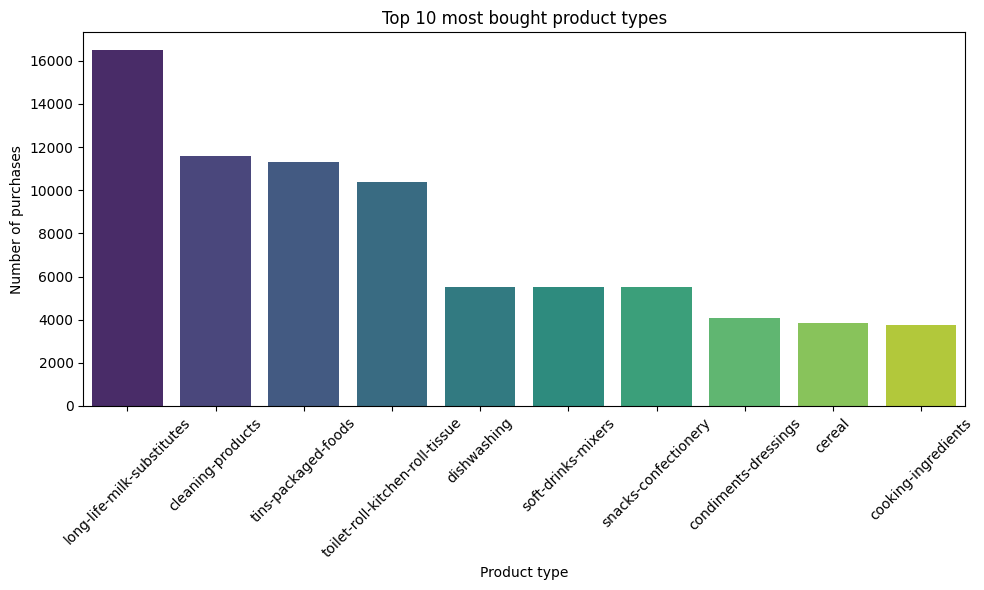

In [29]:
# Plot of most bought items

plt.figure(figsize=(10, 6))
top_10_most_bought_items = df_purchases['product_type'].value_counts().head(10)
sns.barplot(x=top_10_most_bought_items.index, y=top_10_most_bought_items.values, palette='viridis')
plt.title('Top 10 most bought product types')
plt.xlabel('Product type')
plt.ylabel('Number of purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

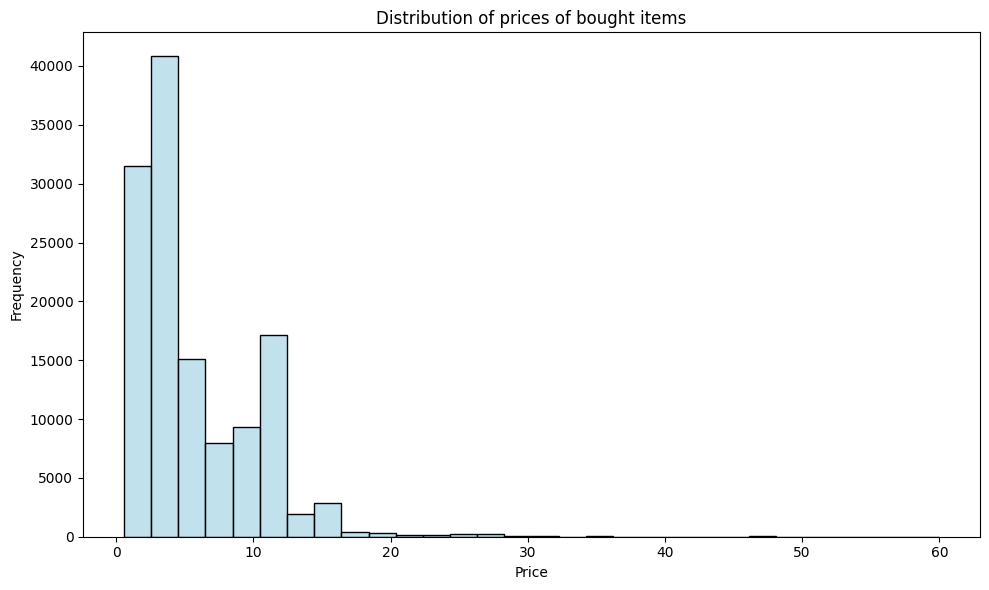

In [36]:
# Distribution of prices of bought items
plt.figure(figsize=(10, 6))
sns.histplot(df_purchases['price'], bins=30, color='lightblue')
plt.title('Distribution of prices of bought items')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

/var/folders/zq/ds7p3rt927gcrx_qw3k8x1zw0000gn/T/ipykernel_6791/2578103875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_purchases['has_discount'] = df_purchases['compare_at_price'] > df_purchases['price']
/var/folders/zq/ds7p3rt927gcrx_qw3k8x1zw0000gn/T/ipykernel_6791/2578103875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='has_discount', data=df_purchases, palette='viridis')


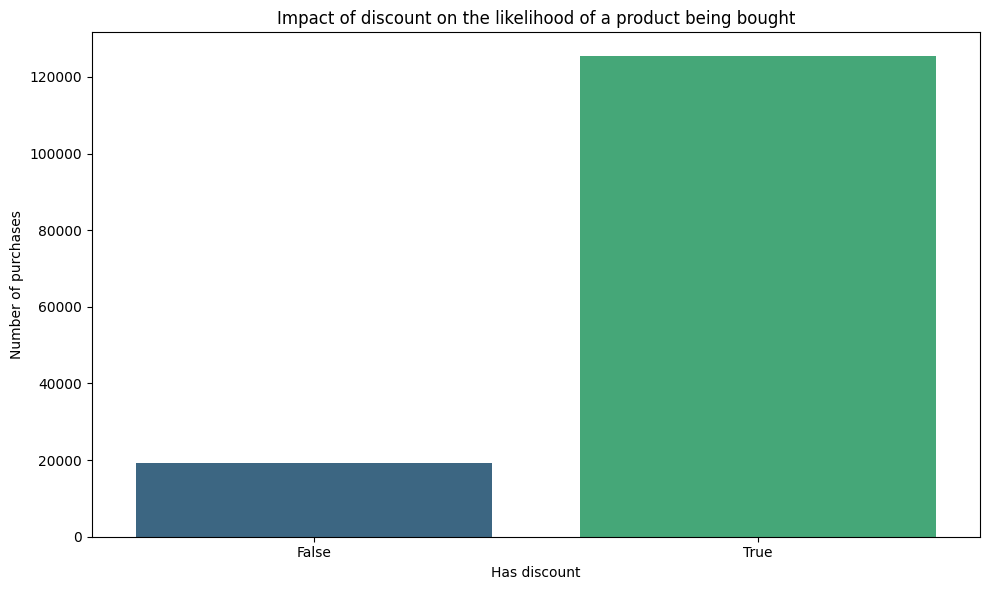

In [37]:
# Impact of discount on the likelihood of a product being bought
df_purchases['has_discount'] = df_purchases['compare_at_price'] > df_purchases['price']
plt.figure(figsize=(10, 6))
sns.countplot(x='has_discount', data=df_purchases, palette='viridis')
plt.title('Impact of discount on the likelihood of a product being bought')
plt.xlabel('Has discount')
plt.ylabel('Number of purchases')
plt.tight_layout()
plt.show()


/var/folders/zq/ds7p3rt927gcrx_qw3k8x1zw0000gn/T/ipykernel_6791/1159867097.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_vendors.values, y=top_10_vendors.index, palette='viridis')


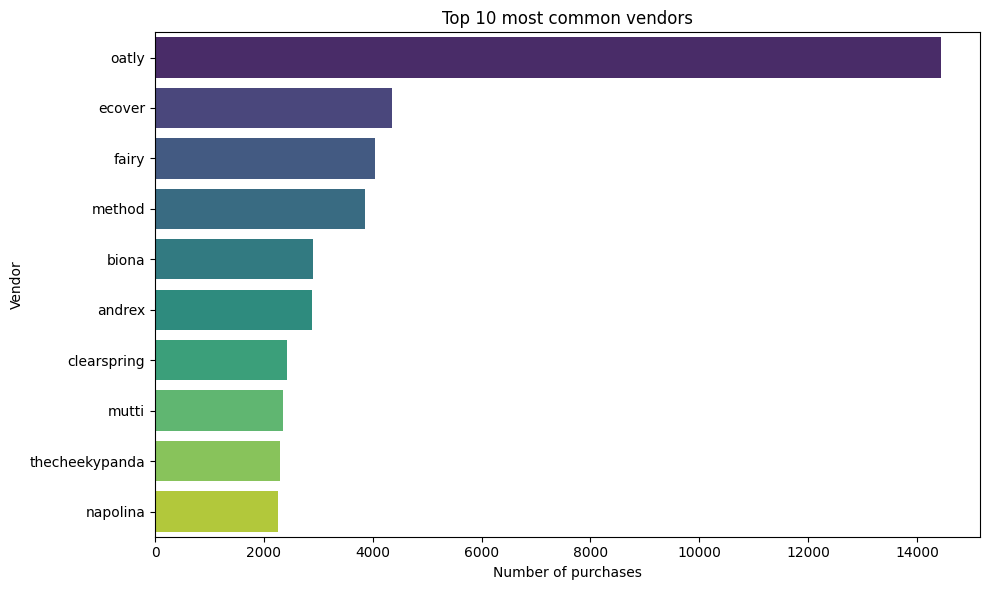

In [38]:
# Most common vendors
plt.figure(figsize=(10, 6))
top_10_vendors = df_purchases['vendor'].value_counts().head(10)
sns.barplot(x=top_10_vendors.values, y=top_10_vendors.index, palette='viridis')
plt.title('Top 10 most common vendors')
plt.xlabel('Number of purchases')
plt.ylabel('Vendor')
plt.tight_layout()  
plt.show()

### 3. Users analysis

We now analyze the users information

In [ ]:
df_unique_users = df_merged.drop_duplicates(subset='user_id')

The dataset contains 4983 unique users.


/var/folders/zq/ds7p3rt927gcrx_qw3k8x1zw0000gn/T/ipykernel_6791/2527321212.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_locations.values, y=top_10_locations.index, palette='viridis', ax=axes[0])
/var/folders/zq/ds7p3rt927gcrx_qw3k8x1zw0000gn/T/ipykernel_6791/2527321212.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_locations_bought.values, y=top_10_locations_bought.index, palette='viridis', ax=axes[1])


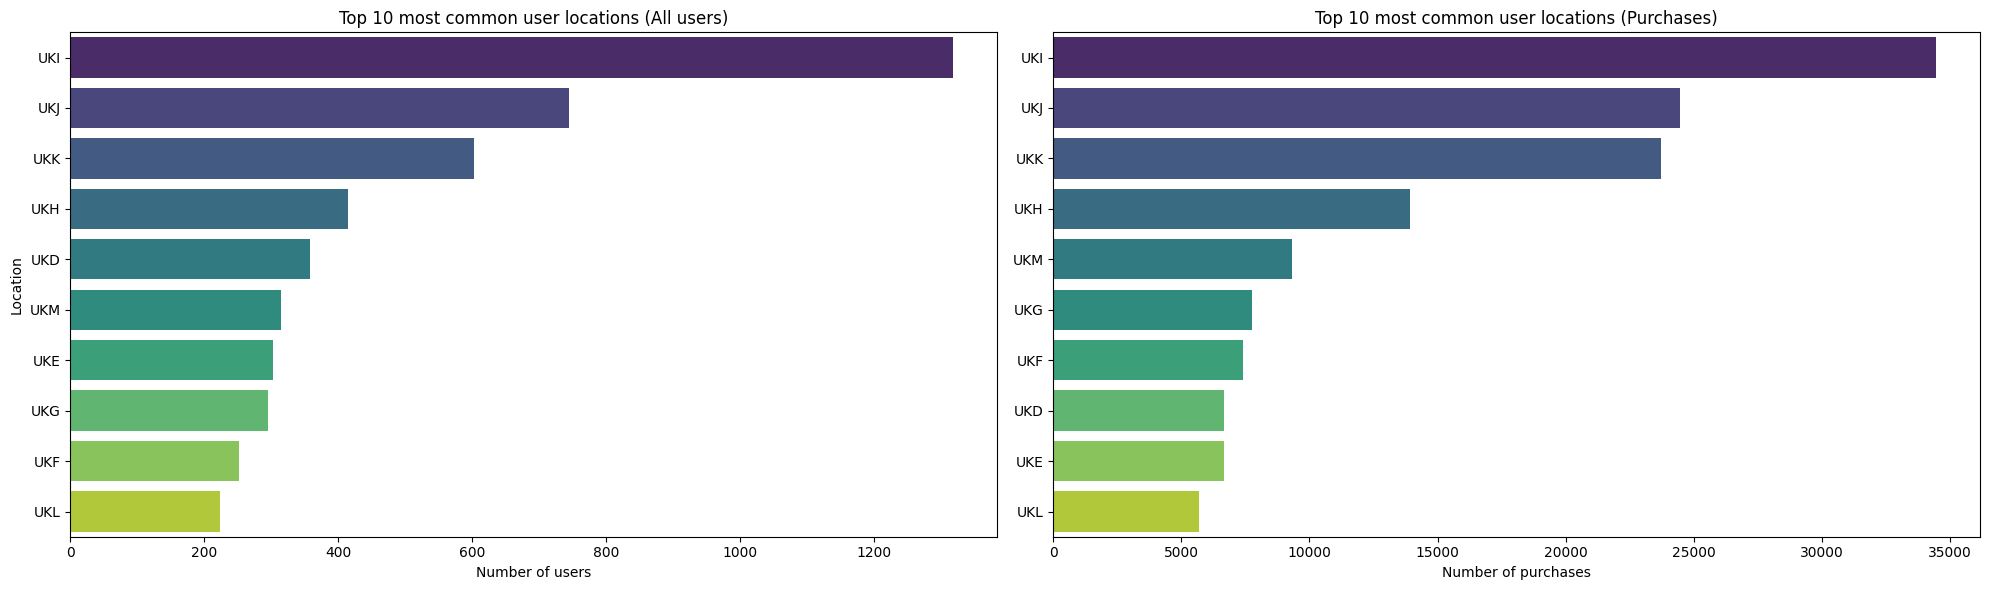

In [47]:
# We combine 2 plots: one with the most common user locations among all users, and another one 
# with the most common user locations among users that bought products
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# More common user locations
top_10_locations = df_unique_users['user_nuts1'].value_counts().head(10)
sns.barplot(x=top_10_locations.values, y=top_10_locations.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 most common user locations (All users)')
axes[0].set_xlabel('Number of users')
axes[0].set_ylabel('Location')

# More common user locations among users that bought products
top_10_locations_bought = df_purchases['user_nuts1'].value_counts().head(10)
sns.barplot(x=top_10_locations_bought.values, y=top_10_locations_bought.index, palette='viridis', ax=axes[1])
axes[1].set_title('Top 10 most common user locations (Purchases)')
axes[1].set_xlabel('Number of purchases')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

/var/folders/zq/ds7p3rt927gcrx_qw3k8x1zw0000gn/T/ipykernel_6791/3618534606.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_segments.values, y=top_10_segments.index, palette='viridis')


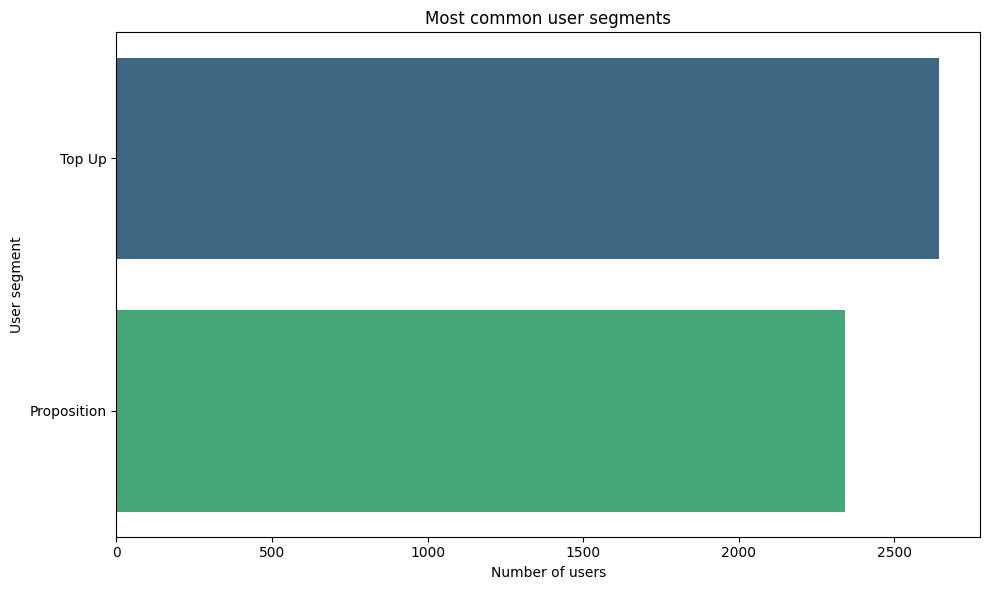

In [42]:
# More common user segments
plt.figure(figsize=(10, 6))
top_10_segments = df_unique_users['user_segment'].value_counts().head(10)
sns.barplot(x=top_10_segments.values, y=top_10_segments.index, palette='viridis')
plt.title('Most common user segments')   
plt.xlabel('Number of users')
plt.ylabel('User segment')
plt.tight_layout()
plt.show()

/var/folders/zq/ds7p3rt927gcrx_qw3k8x1zw0000gn/T/ipykernel_6791/3215552244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='user_segment', y='price', data=df_purchases, palette='viridis')


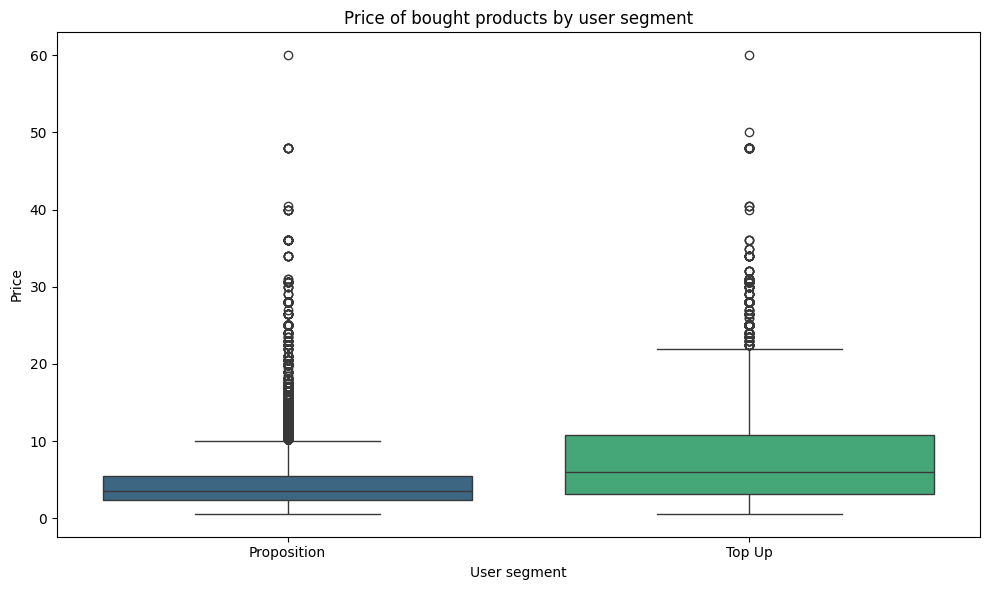

In [44]:
# Do Top Up users buy more expensive products than other users?
plt.figure(figsize=(10, 6))
sns.boxplot(x='user_segment', y='price', data=df_purchases, palette='viridis')
plt.title('Price of bought products by user segment')
plt.xlabel('User segment')
plt.ylabel('Price')     
plt.tight_layout()
plt.show()

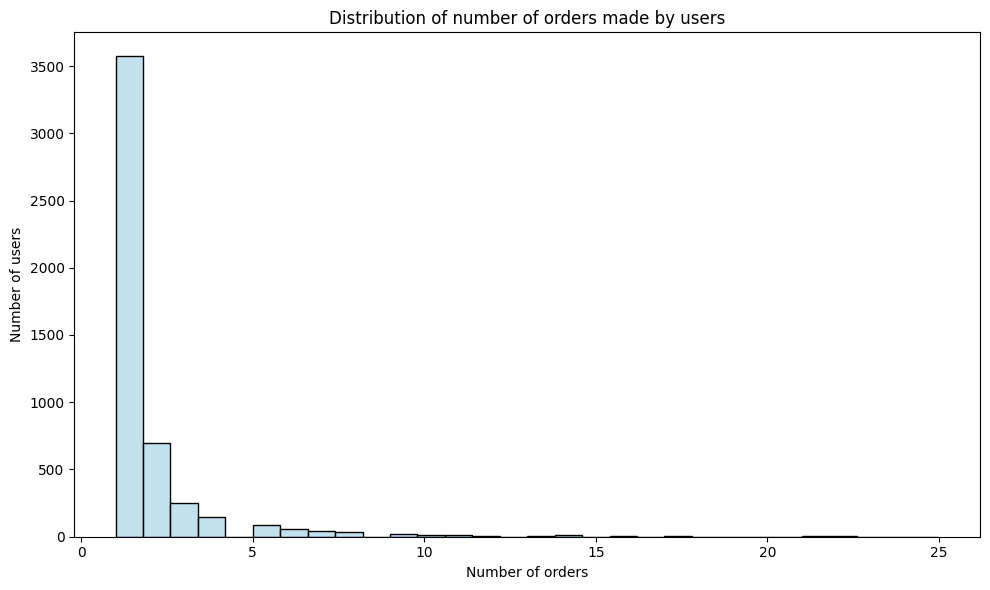

In [46]:
# We now analyze the number of orders made by users
plt.figure(figsize=(10, 6))
fidelity = df_orders.groupby('user_id')['user_order_seq'].max()
sns.histplot(fidelity, bins=30, color='lightblue')
plt.title('Distribution of number of orders made by users')
plt.xlabel('Number of orders')
plt.ylabel('Number of users')
plt.tight_layout()
plt.show()

These graphs have given us a lot of information about our dataset (and we could keep digging into the data), which gives us a sense of the data and we could now start our modelling step to improve the conversion rate of abandoned items or asked items or for something else.